In [4]:
import pypsa
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pypsa.plot.maps.static import add_legend_circles, add_legend_patches
from IPython.display import display

# Energy Mix
This notebook includes scripts to evaluate the energy mix in different ways:
1) Energy mix by energy source and bus
2) Energy mix by carrier and differences compared to baseline

## 1 - Energy mix by energy source and bus
This analysis is mainly intended for baseline scenarios:
- energy source type: fossil, renewables, other low-carbon (nuclear and allam)
- interconnections between buses are shown (the blue ones refer to submarine power cables)
- grid scores are shown: RES only includes renewables, CFE includes renewables + other low-carbon (scores = yearly energy share)

In [5]:
# 0 - Helpers
def get_network_path(scenario, path = False):
    """
    Retrieve the network file path for a given scenario.
    
    - path = False means the default model repo path is used --> go back one level and go to "results/{scenario}/networks/network.nc"
    - path = "custom-path" means the networks are saved in a custom path where the network name is the same as the scenario name --> "custom-path/{scenario}.nc"
    """

    if not path: # Default model repo path: go back one level and go to results/...
        # Define the scenario directory
        scenario_dir = os.path.join("..", f"results/{scenario}/networks")
        if not os.path.exists(scenario_dir):
            print(f"Scenario directory {scenario_dir} not found, skipping.")
            return None
        
        # Get scenario network file
        nc_files = [f for f in os.listdir(scenario_dir) if f.endswith(".nc")]
        if not nc_files:
            print(f"Scenario network file not found in {scenario_dir}, skipping.")
            return None
        
        network_path = os.path.join(scenario_dir, nc_files[0])
        
    else: # If a custom path is provided, where the network name is the same as the scenario name
        # Define the scenario directory
        scenario_dir = path

        # Get scenario network file
        network_path = f"{scenario_dir}/{scenario}.nc"
        if not os.path.exists(network_path):
            print(f"{scenario} network file not found in {scenario_dir}, skipping.")
            return None

    return network_path


def plot_grid_score(n, scenario, df_gen=False):
    """Plotmap the energy mix by energy source and bus."""

    def load_projection(plotting_params):
        """Load the projection for the plot."""

        proj_kwargs = plotting_params.get("projection", dict(name="EqualEarth"))
        proj_func = getattr(ccrs, proj_kwargs.pop("name"))
        return proj_func(**proj_kwargs)
    
    def calculate_global_score(n, name, weights):
        """Calculate a grid score."""

        name_p = n.buses_t[f"{name}_p"]
        name_all_p = n.buses_t[f"{name}_all_p"]
        
        numerator = (weights @ name_p).sum()
        denominator = (weights @ name_all_p).sum()
        
        return round(numerator / denominator * 100)
    
    def get_cap_by_source_country(n, df):
        """Get generation capacity by source and country."""

        bus_to_country = n.buses["country"].to_dict()
        df_summary = df.reset_index()
        df_summary["country"] = df_summary["bus"].map(bus_to_country)
        df_summary = (df_summary.set_index("country").drop(columns=["bus"]).groupby(["country","carrier"]).sum().unstack()/1e3).round(2) # GWh to TWh
        df_summary.columns = df_summary.columns.droplevel(0)
        df_summary.columns.name = None
        print(f"Gross generation: {round(df_summary.sum().sum(),0)} TWh") 
        print(f"Gross generation by country and by source (TWh)")

        # Display entire table without truncation
        with pd.option_context('display.max_rows', None, 'display.max_columns', None):
            display(df_summary.T)

    
    bus_size_factor = 1e5
    legend_circles = [100, 50, 30, 10]
    
    # Weights and energy calculations
    weights = n.snapshot_weightings["generators"]
    
    # Create DataFrame
    df = pd.DataFrame({
        "Renewable sources": weights @ n.buses_t["res_w_ci_p"],
        "Other low-carbon sources": weights @ (n.buses_t["cfe_w_ci_p"] - n.buses_t["res_w_ci_p"]),
        "Fossil sources": weights @ (n.buses_t["cfe_w_ci_all_p"]- n.buses_t["cfe_w_ci_p"])
    })
    
    # Fill missing values and convert to GWh
    df = df.fillna(0).div(1e3)
    
    # Reshape and aggregate
    df.index.name = "bus"
    df = df.reset_index().melt(id_vars=["bus"], value_vars=df.columns, var_name="carrier", value_name="Value")
    df = df.groupby(["bus", "carrier"]).sum()
    df = df.where(df > 1e-4, 0).Value
    

    # Colors for carriers
    colors = {
        "Renewable sources": "#32CD32",
        "Other low-carbon sources": "#adadad",
        "Fossil sources": "#692e0a"
    }
    
    # Projection and plot setup
    proj = load_projection({})
    
    fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": proj})
    
    # Bus sizes and link widths
    bus_sizes = df / bus_size_factor
    link_widths = (n.links.carrier == "DC").astype(int)
    
    # Plot network
    n.plot(
        geomap=True,
        bus_sizes=bus_sizes,
        bus_colors=colors,
        line_colors="Black",
        link_colors="Blue",
        link_widths=link_widths,
        branch_components=["Link", "Line"],
        ax=ax,
        boundaries = [-11, 30, 34, 71]
    )
    
    # --- Add Title ---
    ax.set_title(f"{scenario} energy mix")
    
    # --- Legend schemes ---
    legend_x, legend_y = 1.0, 0.5
    global_cfe_score = calculate_global_score(n, "cfe_w_ci", weights)
    global_res_score = calculate_global_score(n, "res_w_ci", weights)
    description = f"Global Score\nCFE Score: {global_cfe_score}%\nRES Score: {global_res_score}%"
    
    ax.text(
        legend_x + 0.18, legend_y, description, transform=ax.transAxes, verticalalignment='center',horizontalalignment="center",
        bbox=dict(facecolor='white', edgecolor='lightgrey', boxstyle='round,pad=1')
    )
    
    # --- Bus sizes legend ---
    sizes = [s * 1e3 / bus_size_factor for s in legend_circles]
    labels = [f"{s} TWh" for s in legend_circles]
    
    legend_kw = {
        "loc": "upper left",
        "bbox_to_anchor": (legend_x, 1.0),
        "labelspacing": 0.9,
        "handletextpad": 0,
        "frameon": False,
        "title": r"Energy Generation",
    }
    
    add_legend_circles(
        ax,
        sizes,
        labels,
        srid=n.srid,
        patch_kw={"facecolor": "lightgrey"},
        legend_kw=legend_kw,
    )
    
    # --- Carrier patches legend ---
    carriers = df[df > 0].index.get_level_values(1).unique()
    legend_colors = [colors[c] for c in carriers]
    legend_labels = list(carriers)
    
    legend_kw.update({
        "loc": "upper left",
        "bbox_to_anchor": (legend_x, legend_y - 0.25),
        "handletextpad": 0.2,
        "title": r"Energy Type",
        "alignment": "center",
        "ncol": 1
    })
    
    add_legend_patches(
        ax,
        legend_colors,
        legend_labels,
        legend_kw=legend_kw
    )

    os.makedirs("figures", exist_ok=True)
    fig.savefig(f"figures/energy_mix_by_source_bus_{scenario}", dpi=300, bbox_inches="tight")

    if df_gen:
        get_cap_by_source_country(n, df)


--------Planning Horizon: 2025--------


INFO:pypsa.io:Imported network baseline-2025-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
/tmp/ipykernel_158589/3592633737.py:116: DeprecatedWarning: plot is deprecated. Use `n.plot.map()` as a drop-in replacement instead.
  n.plot(
/home/user/miniforge3/envs/metastudy/lib/python3.12/site-packages/pypsa/plot/maps/static.py:1678: UserWarning: When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend circle sizes.
  warnings.warn(


--------Scenario: baseline-2025-1H--------
Scenario directory ../results/baseline-2025-NoResTargets-1H/networks not found, skipping.
--------Planning Horizon: 2030--------


INFO:pypsa.io:Imported network baseline-2030-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
/tmp/ipykernel_158589/3592633737.py:116: DeprecatedWarning: plot is deprecated. Use `n.plot.map()` as a drop-in replacement instead.
  n.plot(
/home/user/miniforge3/envs/metastudy/lib/python3.12/site-packages/pypsa/plot/maps/static.py:1678: UserWarning: When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend circle sizes.
  warnings.warn(


--------Scenario: baseline-2030-1H--------


INFO:pypsa.io:Imported network baseline-2030-NoResTargets-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
/tmp/ipykernel_158589/3592633737.py:116: DeprecatedWarning: plot is deprecated. Use `n.plot.map()` as a drop-in replacement instead.
  n.plot(
/home/user/miniforge3/envs/metastudy/lib/python3.12/site-packages/pypsa/plot/maps/static.py:1678: UserWarning: When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend circle sizes.
  warnings.warn(


--------Scenario: baseline-2030-NoResTargets-1H--------


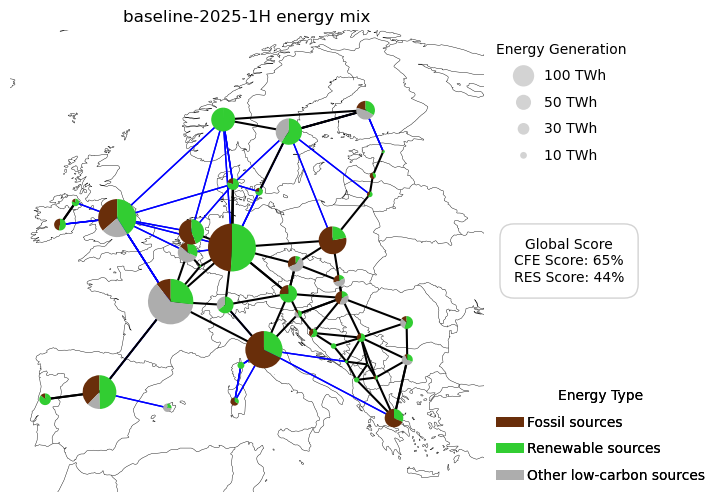

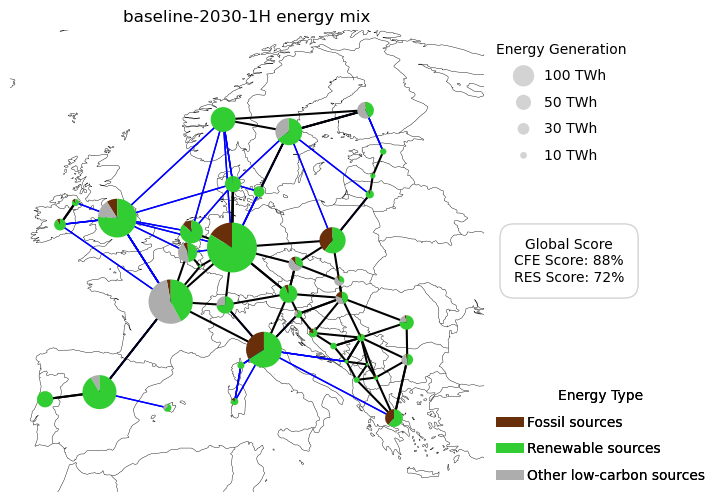

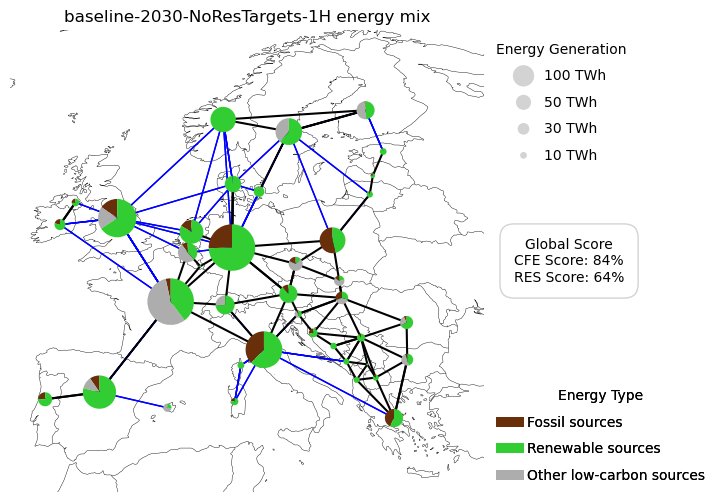

In [6]:
# 1 - Retrieve results
planning_horizon_list = ["2025", "2030"]
time_resolution = "1"

for planning_horizon in planning_horizon_list:
    print(f"--------Planning Horizon: {planning_horizon}--------")

    scenarios = [f"baseline-{planning_horizon}-{time_resolution}H",
                 f"baseline-{planning_horizon}-NoResTargets-{time_resolution}H"
                ]
    
    for scenario in scenarios:
        network_path = get_network_path(scenario, path = False)

        if network_path is None: # if the scenario is not found (either the folder or the network in the folder)
            continue
        
        network = pypsa.Network(network_path)
        print(f"--------Scenario: {scenario}--------")
        plot_grid_score(network, scenario, df_gen = False) # switch df_gen to True to get generation by source (Fossil, RES, Other low-carbon) and country

## 2 - Energy mix by carrier (EU level) and differences compared to baseline

In [7]:
# 0 - Helpers
def get_network_path(scenario, path = False):
    """
    Retrieve the network file path for a given scenario.
    
    - path = False means the default model repo path is used --> go back one level and go to "results/{scenario}/networks/network.nc"
    - path = "custom-path" means the networks are saved in a custom path where the network name is the same as the scenario name --> "custom-path/{scenario}.nc"
    """

    if not path: # Default model repo path: go back one level and go to results/...
        # Define the scenario directory
        scenario_dir = os.path.join("..", f"results/{scenario}/networks")
        if not os.path.exists(scenario_dir):
            print(f"Scenario directory {scenario_dir} not found, skipping.")
            return None
        
        # Get scenario network file
        nc_files = [f for f in os.listdir(scenario_dir) if f.endswith(".nc")]
        if not nc_files:
            print(f"Scenario network file not found in {scenario_dir}, skipping.")
            return None
        
        network_path = os.path.join(scenario_dir, nc_files[0])
        
    else: # If a custom path is provided, where the network name is the same as the scenario name
        # Define the scenario directory
        scenario_dir = path

        # Get scenario network file
        network_path = f"{scenario_dir}/{scenario}.nc"
        if not os.path.exists(network_path):
            print(f"{scenario} network file not found in {scenario_dir}, skipping.")
            return None

    return network_path

carrier_map = {
    "solar rooftop": "Solar-rooftop",
    "solar": "Solar",
    "solar-hsat": "Solar-hsat",
    "onwind": "Wind-onshore",
    "offwind-dc": "Wind-offshore-dc",
    "offwind-ac": "Wind-offshore-ac",
    "offwind-float": "Wind-offshore-float",
    "ror": "Hydro",
    "hydro": "Hydro",
    "geothermal": "Geothermal",
    "OCGT": "Gas",
    "CCGT": "Gas",
    "allam": "Gas with CCS",
    "nuclear": "Nuclear",
    "oil": "Oil",
    "lignite": "Coal",
    "coal": "Coal",
    "urban central gas CHP": "Gas",
    "urban central gas CHP CC": "Gas with CCS",
    "urban central solid biomass CHP": "Biomass",
    "urban central solid biomass CHP CC": "Biomass with CCS",
    "H2 Fuel Cell": "Hydrogen",
    "li-ion battery discharger": "Li-ion battery",
    "li-ion home battery discharger": "Li-ion battery",
    "li-ion battery - CI" : "Li-ion battery"
}

carrier_to_exclude = ["AC",
                      "DC",
                      "electricity distribution grid",
                      "H2 Fuel Cell",
                      "H2 Electrolysis",
                      "li-ion battery charger",
                      "li-ion home battery charger",
                      "PHS",
                      "li-ion battery 8h"]

def get_energy_balance(n, carrier_to_exclude, scenario, display_table=False):
    """Get the energy balance for a given scenario."""
    bus_AC = n.buses.query("carrier == 'AC'").index
    bus_low_voltage = n.buses[n.buses.index.str.contains("low voltage")].index

    df = pd.DataFrame(n.statistics.energy_balance(nice_names = False, comps = ["Generator", "Link", "StorageUnit", "Store"], groupby=["carrier","bus"]))
    df = df.loc[(df.index.get_level_values('bus').isin(bus_AC) | (df.index.get_level_values('bus').isin(bus_low_voltage))) &
                (~df.index.get_level_values('carrier').isin(carrier_to_exclude))
                ]
    df = round(df.groupby(level=[1]).sum()/10**6,2) # MWh to TWh
    df.rename(columns={0: scenario}, inplace=True)

    # Add storage unit output:
    # using p_dispatch instead of n.statistics.energy_balance to be conservative.
    # Indeed, the latter accounts for `p = p_dispatch - p_store`.
    # Also, by using n.statistics.supply (which accounts for p.cip(lower=0))would not be consistent in case p_dispatch and p_store occurs simultaneously.
    sto_i = n.storage_units[n.storage_units.ci != ""].index if "ci" in n.storage_units.columns else []
    sto_unit_output = (n.storage_units_t.p_dispatch[sto_i].multiply(n.snapshot_weightings["generators"], axis=0).sum().sum()/1e6) if not n.storage_units_t.p_dispatch.empty else 0
    df.loc["li-ion battery - CI"] = sto_unit_output

    print(f"Gross generation (TWh): {round(df[~df.index.isin(['li-ion battery discharger', 'li-ion home battery discharger', 'li-ion battery - CI'])].sum().values[0], 2)}")
    if display_table:
        print(f"Gross generation by carrier (TWh):")
        display(df.style.format("{:.2f}"))
    return df

In [8]:
# 1 - Process energy balance
planning_horizon_list = ["2025", "2030"]
time_resolution = "1"
ci_participation = "25"
scenario_year = {}
df_year = {}
for planning_horizon in planning_horizon_list:
    print(f"--------Planning Horizon: {planning_horizon}--------")

    scenarios = [f"baseline-{planning_horizon}-{time_resolution}H",
                f"vol-match-{planning_horizon}-ci{ci_participation}-{time_resolution}H",
                f"vol-match-{planning_horizon}-country-ci{ci_participation}-{time_resolution}H", # only for 2030
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe100-{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe90-{time_resolution}H",
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-aer-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-mber-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-moer-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-cmer-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-aer-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-mber-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-moer-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-cmer-{time_resolution}H", # only for 2030
                f"baseline-{planning_horizon}-NoResTargets-{time_resolution}H", # only for 2030
                f"vol-match-{planning_horizon}-NoResTargets-ci{ci_participation}-{time_resolution}H", # only for 2030
                ]
    
    dfs = []
    scenario_year[planning_horizon] = []

    for scenario in scenarios:
        network_path = get_network_path(scenario, path = False)

        if network_path is None: # if the scenario is not found (either the folder or the network in the folder)
            continue

        network = pypsa.Network(network_path)
        print(f"----Scenario: {scenario}----")
        df = get_energy_balance(network, carrier_to_exclude, scenario, display_table=False)
        dfs.append(df)
        scenario_year[planning_horizon].append(scenario)

    df_year[planning_horizon] = dfs

--------Planning Horizon: 2025--------


INFO:pypsa.io:Imported network baseline-2025-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: baseline-2025-1H----
Gross generation (TWh): 3205.68


INFO:pypsa.io:Imported network vol-match-2025-ci25-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: vol-match-2025-ci25-1H----
Gross generation (TWh): 3237.44
Scenario directory ../results/vol-match-2025-country-ci25-1H/networks not found, skipping.


...

----Scenario: emi-match-2030-ci25-model-cmer-1H----
Gross generation (TWh): 3257.01


INFO:pypsa.io:Imported network baseline-2030-NoResTargets-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: baseline-2030-NoResTargets-1H----
Gross generation (TWh): 3237.45


INFO:pypsa.io:Imported network vol-match-2030-NoResTargets-ci25-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: vol-match-2030-NoResTargets-ci25-1H----
Gross generation (TWh): 3238.27


--------Changes Compared to Baseline - Planning Horizon: 2025--------
Difference compared to baseline, carriers contributing less than 1 TWh excluded (TWh):



vol-match-2025-ci25-1H               30.93
247-cfe-2025-ci25-cfe100-1H         117.62
247-cfe-2025-ci25-cfe90-1H           79.10
emi-match-2025-ci25-data-aer-1H      30.43
emi-match-2025-ci25-data-mber-1H     28.42
emi-match-2025-ci25-data-moer-1H     30.61
emi-match-2025-ci25-data-cmer-1H     29.71
dtype: float64


Difference compare to baseline, by carrier, carriers contributing less than 1 TWh excluded (TWh):


,vol-match-2025-ci25-1H,247-cfe-2025-ci25-cfe100-1H,247-cfe-2025-ci25-cfe90-1H,emi-match-2025-ci25-data-aer-1H,emi-match-2025-ci25-data-mber-1H,emi-match-2025-ci25-data-moer-1H,emi-match-2025-ci25-data-cmer-1H
carrier,,,,,,,
CCGT,-373.36,-431.81,-388.49,-373.89,-380.97,-374.54,-378.22
coal,-37.26,-17.28,-15.07,-38.23,-38.31,-38.49,-39.20
li-ion home battery discharger,-0.90,-0.90,-0.90,-0.90,-0.90,-0.90,-0.90
lignite,-5.54,-7.28,-7.05,-5.59,-5.70,-5.66,-5.78
nuclear,-18.38,-1.76,-1.75,-18.15,-17.33,-18.02,-16.61
offwind-ac,-0.03,77.54,68.34,-3.43,-2.62,-2.46,-2.10
onwind,170.09,20.15,15.21,168.14,121.08,163.47,132.13
solar,-1.87,257.21,15.09,-1.53,-0.59,-1.17,-0.43
li-ion battery - CI,0.00,96.54,61.48,0.00,0.00,0.00,0.00


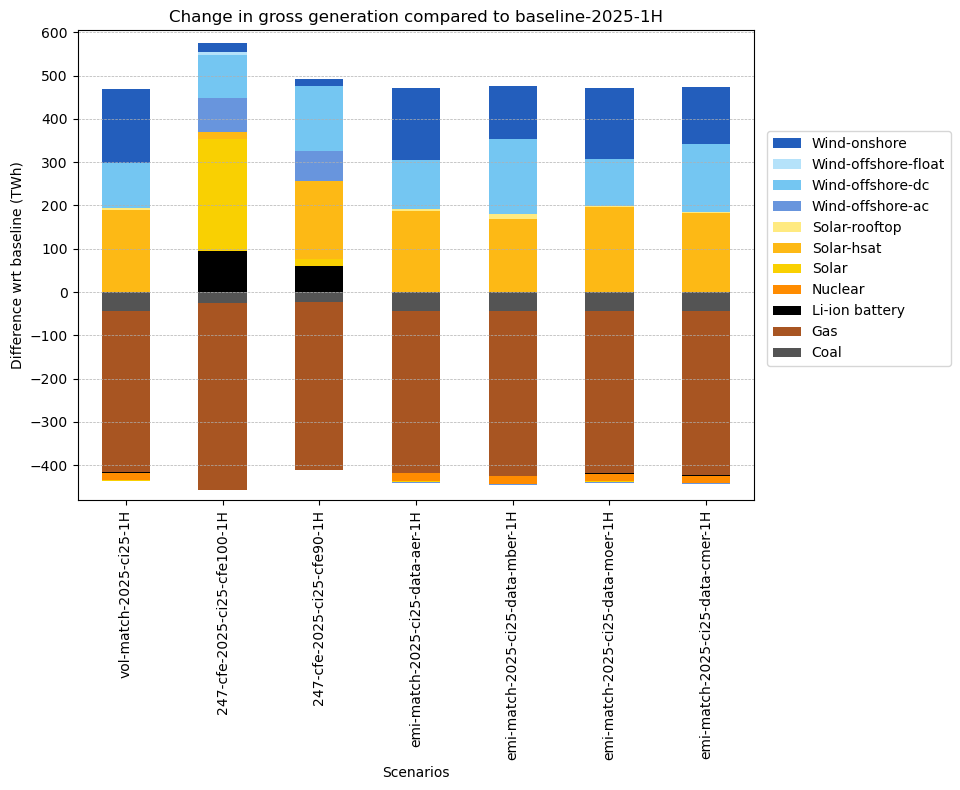

--------Changes Compared to Baseline - Planning Horizon: 2030--------
Difference compared to baseline, carriers contributing less than 1 TWh excluded (TWh):



vol-match-2030-ci25-1H                 13.68
vol-match-2030-country-ci25-1H          0.30
247-cfe-2030-ci25-cfe100-1H             8.14
247-cfe-2030-ci25-cfe90-1H              0.04
emi-match-2030-ci25-model-aer-1H      -13.30
emi-match-2030-ci25-model-mber-1H     -11.37
emi-match-2030-ci25-model-cmer-1H       0.75
vol-match-2030-NoResTargets-ci25-1H     1.25
dtype: float64


Difference compare to baseline, by carrier, carriers contributing less than 1 TWh excluded (TWh).
Consider that for vol-match-2030-NoResTargets-ci25-1H the difference is compared to the baseline scenario without RES targets:


,vol-match-2030-ci25-1H,vol-match-2030-country-ci25-1H,247-cfe-2030-ci25-cfe100-1H,247-cfe-2030-ci25-cfe90-1H,emi-match-2030-ci25-model-aer-1H,emi-match-2030-ci25-model-mber-1H,emi-match-2030-ci25-model-cmer-1H,vol-match-2030-NoResTargets-ci25-1H
carrier,,,,,,,,
CCGT,0.60,7.48,-53.96,-58.15,-29.73,-17.64,0.56,-2.41
coal,0.22,-5.05,2.18,-3.63,-12.11,-0.80,0.25,-0.11
li-ion battery discharger,0.63,-0.76,-14.47,-14.47,-1.88,-0.88,-0.84,0.00
li-ion home battery discharger,9.91,0.95,-25.26,-19.67,-2.49,-0.48,2.03,0.36
lignite,0.02,-0.05,-0.98,-1.00,-0.14,-0.06,0.03,0.00
nuclear,0.04,-2.37,51.36,32.97,-0.68,-1.65,-0.96,-0.90
offwind-ac,-3.07,2.38,158.89,155.16,8.85,-8.29,-13.83,-4.77
offwind-dc,-5.09,3.49,-43.21,71.72,57.12,-1.75,9.91,-1.22
offwind-float,0.00,0.00,5.88,0.58,0.00,0.00,0.00,0.00


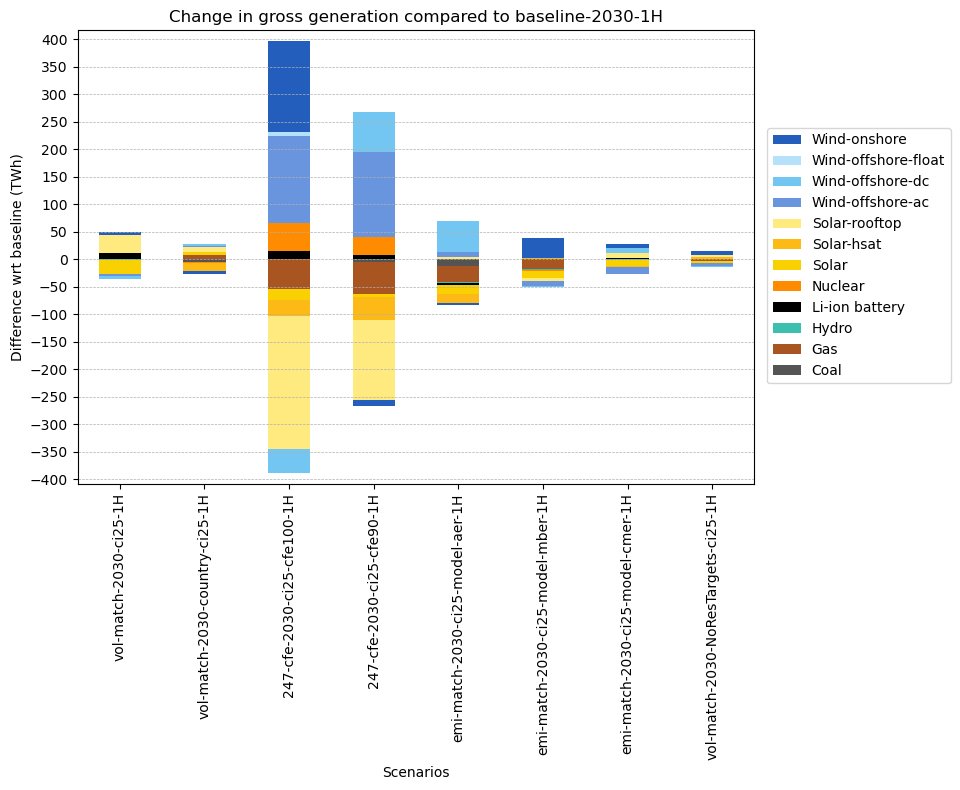

In [9]:
# 2 - Evaluate the differences compared to baseline scenarios
for planning_horizon, dfs in df_year.items():
    print(f"--------Changes Compared to Baseline - Planning Horizon: {planning_horizon}--------")
    df_concat = pd.concat(dfs, axis=1)
    df_concat.fillna(0, inplace=True)
    scenarios = scenario_year[planning_horizon]

    if planning_horizon == "2030":
        df_diff = df_concat.iloc[:, 1:-2].subtract(df_concat.iloc[:, 0], axis=0) # excluding the NoResTargets scenarios
        last_diff = df_concat.iloc[:, -1] - df_concat.iloc[:, -2] # it makes sense to compare the vol-match NoResTargets with the corresponding baseline w/o res targets
        df_diff[df_concat.columns[-1]] = last_diff
        # Remove the baseline-2030-NoResTargets-{time_resolution}H scenario from the list for plotting
        scenarios_diff = [s for s in scenarios if s != f"baseline-2030-NoResTargets-{time_resolution}H"]
        additional_description = f".\nConsider that for {scenarios_diff[-1]} the difference is compared to the baseline scenario without RES targets:"
    else:
        df_diff = df_concat.iloc[:, 1:].subtract(df_concat.iloc[:, 0], axis=0)
        scenarios_diff = scenarios
        additional_description = ":"

    for scenario in scenarios_diff[1:]:
        total_change = df_diff[scenario].sum()
        
    print("Difference compared to baseline, carriers contributing less than 1 TWh excluded (TWh):\n")
    df_diff = df_diff[abs(df_diff.T.sum()) > 1] # Remove carriers contributing less than +-1 TWh
    display(round(df_diff.sum(axis=0),2))

    print(f"\nDifference compare to baseline, by carrier, carriers contributing less than 1 TWh excluded (TWh){additional_description}")
    display(df_diff.style.format("{:.2f}"))

    # 2.1 - Aggregate by carrier_map and prepare color plot
    df_color = pd.Series(
            [network.carriers.color.get(c) or "#000000" for c in df_diff.index],
            index=df_diff.index,
            name="color"
        )
    df_color.rename(index=carrier_map, inplace=True)
    df_color = df_color[~df_color.index.duplicated(keep='first')]
    df_color.sort_index(inplace=True) # to align with df_new, since df_new.index is sorted after we rename the index
    df_color["Li-ion battery"] = "#000000" 
    df_new = df_diff.rename(index=carrier_map)
    df_new = df_new.groupby(level=0).sum()

    # 2.2 - Plot differences compared to baseline by carrier and scenario
    fig, ax = plt.subplots(figsize=(10, 10))

    df_new.T.plot(ax=ax, kind='bar', color=df_color, figsize=(10, 8), stacked=True)
    plt.title(f"Change in gross generation compared to baseline-{planning_horizon}-{time_resolution}H")
    plt.xlabel("Scenarios")
    plt.ylabel("Difference wrt baseline (TWh)")
    ymin = df_new[df_new < 0].sum().min()
    ymax = df_new[df_new > 0].sum().max()
    plt.ylim([1.05*ymin, 1.05*ymax])
    if ymax > 500:
        ymult = 100
    elif 100 < ymax <= 500:
        ymult = 50
    elif 25 < ymax <= 100:
        ymult = 25
    else:
        ymult = 10
    plt.gca().yaxis.set_major_locator(plt.MultipleLocator(ymult))
    plt.grid(axis='y', which='both', linestyle='--', linewidth=0.5)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.3, 0.8))
    plt.tight_layout()
    plt.show()

    os.makedirs("figures", exist_ok=True)
    fig.savefig(f"figures/differences_wrt_baseline-{planning_horizon}-{ci_participation}-{time_resolution}H", dpi=300, bbox_inches="tight")

--------Energy Mix - Planning Horizon: 2025--------


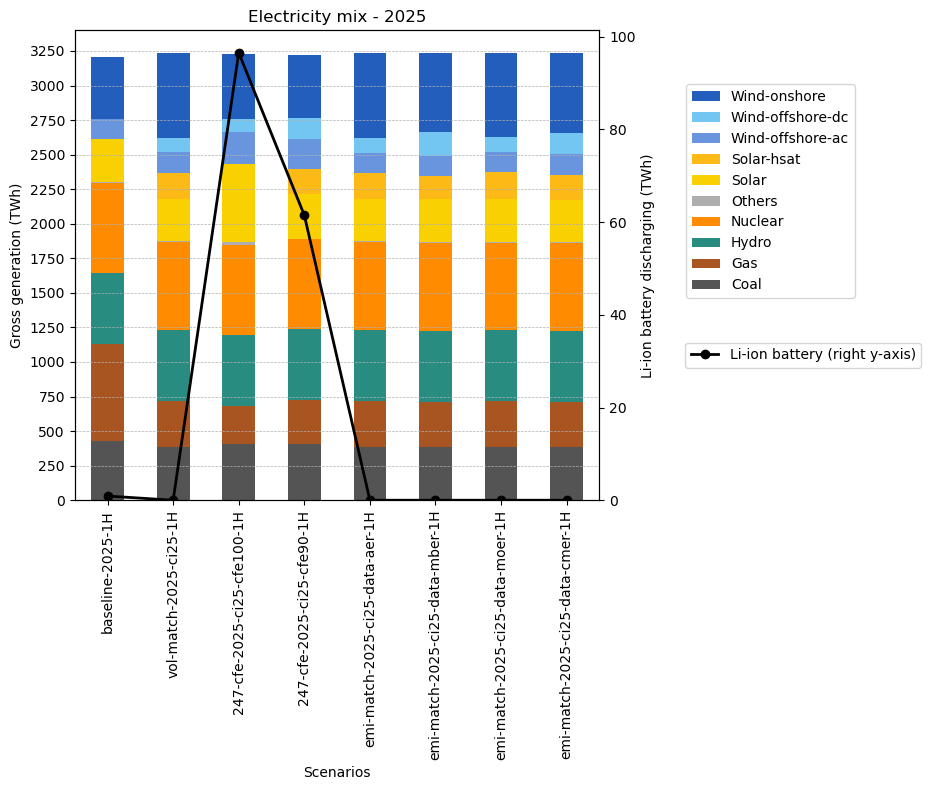

--------Energy Mix - Planning Horizon: 2030--------


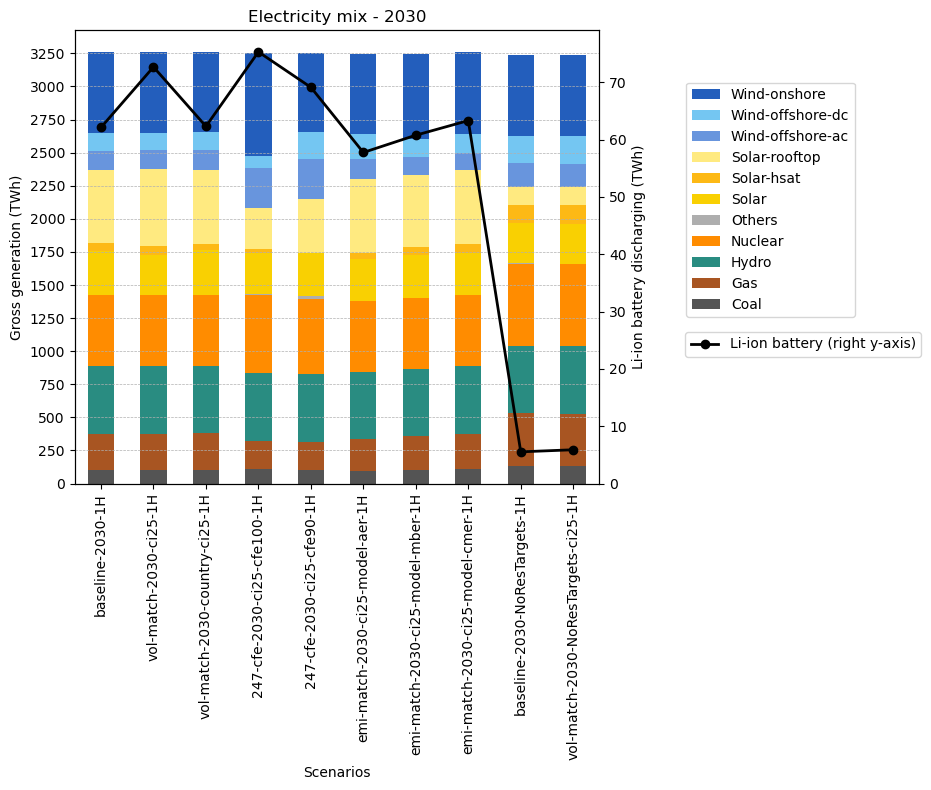

In [10]:
# 3 - Process results for energy mix
for planning_horizon, dfs in df_year.items():
    print(f"--------Energy Mix - Planning Horizon: {planning_horizon}--------")
    df_concat = pd.concat(dfs, axis=1)
    df_concat.fillna(0, inplace=True)

    # Separete carriers below the threshold of 1% of total gross generation into "Others"
    thresholds = df_concat.sum(axis=0) * 0.01
    other_carriers = {}
    df_mod = df_concat.copy()

    for col in df_mod.columns:
        mask = df_mod[col] < thresholds[col]
        other_carriers[col] = df_mod.index[mask].tolist()
        df_mod.loc[mask, col] = np.nan

    other_row = {}
    for col in df_mod.columns:
        carriers_to_sum = [c for c in other_carriers[col] if "battery" not in c]
        other_row[col] = df_concat.loc[carriers_to_sum, col].sum() if carriers_to_sum else np.nan

    df_mod.loc["Others"] = other_row

    df_mod = df_mod.dropna(how='all')

    # 3.1 - Aggregate by carrier_map and prepare color plot
    df_color_mix = pd.Series(
                [network.carriers.color.get(c) or "#000000" for c in df_mod.index],
                index=df_mod.index,
                name="color"
            )
    df_color_mix.rename(index=carrier_map, inplace=True)
    df_color_mix = df_color_mix[~df_color_mix.index.duplicated(keep='first')]
    df_color_mix.sort_index(inplace=True) # to align with df_new, since df_new.index is sorted after we rename the index
    df_color_mix.loc["Li-ion battery"] = "#000000" 
    df_color_mix_mod = df_color_mix.drop("Li-ion battery", errors="ignore")
    df_color_mix_mod.loc["Others"] = "#00000051" 

    df_concat.rename(index=carrier_map, inplace=True)
    df_concat = df_concat.groupby(level=0).sum()

    df_mod_new = df_mod.rename(index=carrier_map)
    df_mod_new = df_mod_new.groupby(level=0).sum()
    df_mod_new = df_mod_new.drop("Li-ion battery", axis=0, errors="ignore")

    # 3.2 - Plot the energy mix by carrier and scenario
    fig, ax = plt.subplots(figsize=(7, 6))

    df_mod_new.T.plot(ax=ax, kind='bar', color=df_color_mix_mod, figsize=(10, 8), stacked=True)
    ax.set_xlabel("Scenarios")
    ax.set_ylabel("Gross generation (TWh)")
    ymax = df_mod_new.sum().max()
    ax.set_ylim([0,1.05*ymax])
    if ymax > 500:
        ymult = 250
    elif 100 < ymax <= 500:
        ymult = 100
    elif 25 < ymax <= 100:
        ymult = 25
    else:
        ymult = 10
    ax.yaxis.set_major_locator(plt.MultipleLocator(ymult))
    ax.grid(axis='y', which='both', linestyle='--', linewidth=0.5)

    # Invert the order of the legend labels
    ax.legend(bbox_to_anchor=(1.15, 1), )
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.5, 0.9))

    # Li-ion battery discharging
    ax2 = ax.twinx()
    df_concat.T.loc[:, "Li-ion battery"].plot(ax=ax2, kind='line', color='k', linewidth=2, marker='o', label="Li-ion battery (right y-axis)")
    ax2.set_ylabel("Li-ion battery discharging (TWh)")

    ymin = df_concat.T.loc[:, "Li-ion battery"].min()
    ymax = df_concat.T.loc[:, "Li-ion battery"].max()
    ax2.set_ylim([0*ymin, 1.05*ymax])

    ax2.legend(bbox_to_anchor=(1.15, 0.35), loc='upper left')

    # save
    plt.title(f"Electricity mix - {planning_horizon}")
    plt.tight_layout()
    plt.show()

    os.makedirs("figures", exist_ok=True)
    fig.savefig(f"figures/energy_mix_by_carrier_scenario-{planning_horizon}-{ci_participation}-{time_resolution}H", dpi=300, bbox_inches="tight")